<a href="https://colab.research.google.com/github/ademimi2008/ml/blob/main/ml_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score, accuracy_score,
                             roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score)

In [2]:
from google.colab import files
uploaded = files.upload()
FILE_NAME = list(uploaded.keys())[0]
df = pd.read_csv(FILE_NAME)      # если файл Excel: pd.read_excel(FILE_NAME)
df.head()

Saving personality_synthetic_dataset.csv to personality_synthetic_dataset.csv


,personality_type,social_energy,alone_time_preference,talkativeness,deep_reflection,group_comfort,party_liking,listening_skill,empathy,creativity,...,spontaneity,adventurousness,reading_habit,sports_interest,online_social_usage,travel_desire,gadget_usage,work_style_collaborative,decision_speed,stress_handling
0,Extrovert,6.794295,3.854670,8.725446,2.515151,7.097368,8.588762,6.774799,6.430132,6.142968,...,4.853313,8.257134,5.270555,10.000000,9.154296,4.816422,9.191711,8.313590,8.032376,7.176905
1,Ambivert,6.378988,5.731157,7.029529,7.274493,4.111199,3.258248,5.550909,3.958179,6.149457,...,6.067201,6.289347,5.753165,5.334303,4.683781,4.725666,5.956141,5.890619,3.158988,3.423577
2,Ambivert,7.459421,6.322263,3.922269,4.622261,5.343276,7.452152,9.483990,6.127654,7.032017,...,5.524244,9.238784,5.250405,3.153540,5.000338,6.139166,6.033048,5.807500,4.571003,5.647480
3,Extrovert,6.159626,3.097837,6.019093,1.965440,7.837140,10.000000,9.436733,8.949684,8.923875,...,4.327018,8.489791,5.312617,8.379936,7.601946,6.370056,5.410145,6.671781,6.600233,5.870088
4,Introvert,5.568462,6.986722,3.913240,9.926161,1.650483,0.362298,7.470387,6.756837,9.507803,...,5.187689,3.167217,7.060235,2.333388,7.771569,5.534336,5.704598,5.832968,5.813099,3.758084


In [5]:
df.info()
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   personality_type          20000 non-null  object 
 1   social_energy             20000 non-null  float64
 2   alone_time_preference     20000 non-null  float64
 3   talkativeness             20000 non-null  float64
 4   deep_reflection           20000 non-null  float64
 5   group_comfort             20000 non-null  float64
 6   party_liking              20000 non-null  float64
 7   listening_skill           20000 non-null  float64
 8   empathy                   20000 non-null  float64
 9   creativity                20000 non-null  float64
 10  organization              20000 non-null  float64
 11  leadership                20000 non-null  float64
 12  risk_taking               20000 non-null  float64
 13  public_speaking_comfort   20000 non-null  float64
 14  curios

In [7]:
print(df.columns.tolist())
print(df['personality_type'].value_counts())

['personality_type', 'social_energy', 'alone_time_preference', 'talkativeness', 'deep_reflection', 'group_comfort', 'party_liking', 'listening_skill', 'empathy', 'creativity', 'organization', 'leadership', 'risk_taking', 'public_speaking_comfort', 'curiosity', 'routine_preference', 'excitement_seeking', 'friendliness', 'emotional_stability', 'planning', 'spontaneity', 'adventurousness', 'reading_habit', 'sports_interest', 'online_social_usage', 'travel_desire', 'gadget_usage', 'work_style_collaborative', 'decision_speed', 'stress_handling']
personality_type
Extrovert    6857
Ambivert     6573
Introvert    6570
Name: count, dtype: int64


In [9]:
# ========== НАСТРОЙКИ ==========
TARGET = 'personality_type'
POSITIVE = 'Introvert'      # положительный класс: Introvert против остальных

C_FP = 1    # цена ложноположительного: назвали человека интровертом, а он нет
C_FN = 5    # цена ложноотрицательного: пропустили настоящего интроверта
            # ЗАМЕНИТЕ на значения из задания преподавателя

NAME_NEG = 'Не интроверт'
NAME_POS = 'Интроверт'
# ===============================

y = (df[TARGET] == POSITIVE).astype(int)
X = df.drop(columns=[TARGET])
print(df[TARGET].value_counts())
print('Доля положительного класса:', round(y.mean(), 3))

personality_type
Extrovert    6857
Ambivert     6573
Introvert    6570
Name: count, dtype: int64
Доля положительного класса: 0.328


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

model = Pipeline([('sc', StandardScaler()),
                  ('clf', LogisticRegression(max_iter=1000))])
model.fit(X_train, y_train)

proba_test = model.predict_proba(X_test)[:, 1]   # вероятности, а не 0/1
print(proba_test[:10].round(3))

[0.    0.    0.    1.    1.    1.    0.    0.    0.999 1.   ]


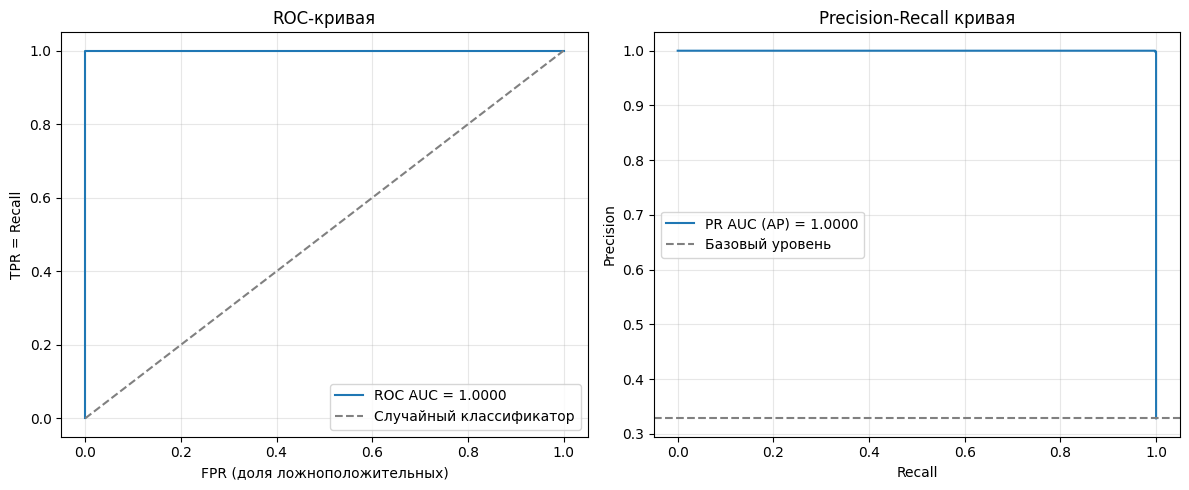

ROC AUC = 1.0000,  PR AUC = 1.0000


In [11]:
fpr, tpr, _ = roc_curve(y_test, proba_test)
roc_auc = roc_auc_score(y_test, proba_test)
prec, rec, _ = precision_recall_curve(y_test, proba_test)
ap = average_precision_score(y_test, proba_test)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')
ax[0].plot([0, 1], [0, 1], '--', color='gray', label='Случайный классификатор')
ax[0].set_xlabel('FPR (доля ложноположительных)')
ax[0].set_ylabel('TPR = Recall')
ax[0].set_title('ROC-кривая')
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(rec, prec, label=f'PR AUC (AP) = {ap:.4f}')
ax[1].axhline(y_test.mean(), ls='--', color='gray', label='Базовый уровень')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall кривая')
ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f'ROC AUC = {roc_auc:.4f},  PR AUC = {ap:.4f}')

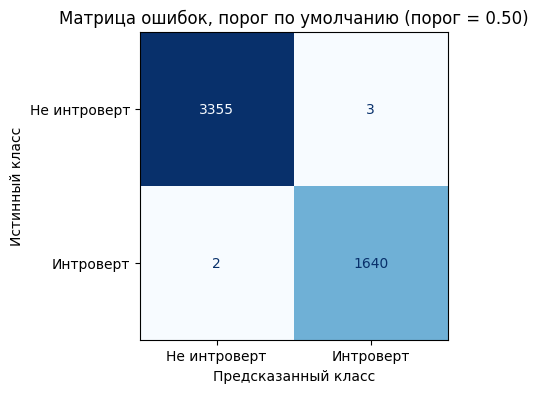

Порог                       0.5000
Accuracy                    0.9990
Precision                   0.9982
Recall                      0.9988
F1                          0.9985
TN                       3355.0000
FP                          3.0000
FN                          2.0000
TP                       1640.0000
Суммарная цена ошибок      13.0000
dtype: float64


In [12]:
def evaluate(y_true, proba, thr, title):
    pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    res = {
        'Порог': thr,
        'Accuracy': accuracy_score(y_true, pred),
        'Precision': precision_score(y_true, pred, zero_division=0),
        'Recall': recall_score(y_true, pred),
        'F1': f1_score(y_true, pred),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'Суммарная цена ошибок': C_FP * fp + C_FN * fn
    }
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, pred, display_labels=[NAME_NEG, NAME_POS],
        cmap='Blues', ax=ax, colorbar=False)
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Истинный класс')
    ax.set_title(f'{title} (порог = {thr:.2f})')
    plt.show()
    return res

res_default = evaluate(y_test, proba_test, 0.5, 'Матрица ошибок, порог по умолчанию')
print(pd.Series(res_default).round(4))

Оптимальный порог: 0.31
Ориентир C_FP/(C_FP+C_FN) = 0.17


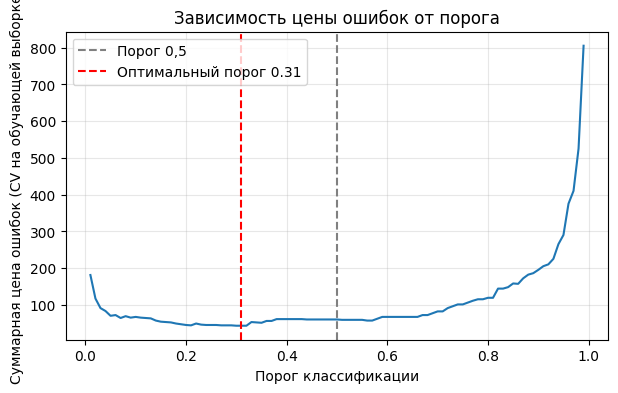

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
proba_cv = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)
costs = []
for t in thresholds:
    pred = (proba_cv >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, pred).ravel()
    costs.append(C_FP * fp + C_FN * fn)
costs = np.array(costs)

# если минимум достигается на плато, берём его середину
best_thr = float(np.median(thresholds[costs == costs.min()]))
print(f'Оптимальный порог: {best_thr:.2f}')
print(f'Ориентир C_FP/(C_FP+C_FN) = {C_FP/(C_FP+C_FN):.2f}')

plt.figure(figsize=(7, 4))
plt.plot(thresholds, costs)
plt.axvline(0.5, ls='--', color='gray', label='Порог 0,5')
plt.axvline(best_thr, ls='--', color='red', label=f'Оптимальный порог {best_thr:.2f}')
plt.xlabel('Порог классификации')
plt.ylabel('Суммарная цена ошибок (CV на обучающей выборке)')
plt.title('Зависимость цены ошибок от порога')
plt.legend(); plt.grid(alpha=0.3); plt.show()

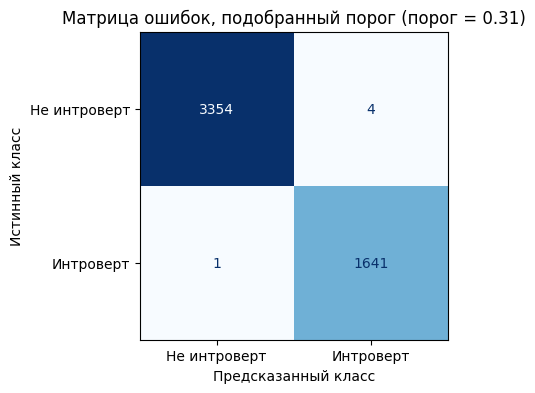

,"Порог 0,5",Порог 0.31
Порог,0.5000,0.3100
Accuracy,0.9990,0.9990
Precision,0.9982,0.9976
Recall,0.9988,0.9994
F1,0.9985,0.9985
TN,3355.0000,3354.0000
FP,3.0000,4.0000
FN,2.0000,1.0000
TP,1640.0000,1641.0000
Суммарная цена ошибок,13.0000,9.0000


In [14]:
res_best = evaluate(y_test, proba_test, best_thr, 'Матрица ошибок, подобранный порог')

comparison = pd.DataFrame({'Порог 0,5': res_default,
                           f'Порог {best_thr:.2f}': res_best}).round(4)
comparison